This code is to faciltate visualization of the snow depth outputs from the ResNet model. 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates
import numpy as np

In [2]:
manual = pd.read_csv('/Users/cmbreen/Documents/snow/alaska_dataset/all_images/labels.csv') # labels used for cam embed trainigs
#automated = pd.read_csv('/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn/predictions/results.csv')
automated = pd.read_csv('/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn_allpoles_camembed_lr1e4/predictions/results.csv')

## metadata for reference
metadata = pd.read_csv('/Users/cmbreen/Documents/snow/alaska_dataset/all_images/pole_metadata.csv')
#metadata2 = pd.read_csv('/Users/cmbreen/Documents/snow/alaska_dataset/all_images/snowfree_photos/BC_final_448/pole_metadata2_BC.csv')

In [3]:
## 
unique_cameras = pd.unique(manual['cameraID'])
print(f'{len(unique_cameras)} camera stations')

unique_cameras = pd.unique(automated['camera_id'])
print(f'{len(unique_cameras)} camera stations')

15 camera stations
15 camera stations


In [4]:
manual

,cameraID,filename,datetime,x1,y1,x2,y2,PixelLengths,SnowDepths,Storm_Flag,Vegetation_Flag,Pole_Tilt_Flag
0,BC11TLSB,BC11TLSB_WSCT1713.JPG,8/20/23 14:00,210.932727,99.281818,208.023636,309.900000,210.638271,0.506899,0,0,0
1,BC11TLSB,BC11TLSB_WSCT1724.JPG,8/23/23 16:00,208.023636,99.572727,210.350909,309.318182,209.758365,1.025626,0,0,0
2,BC11TLSB,BC11TLSB_WSCT1734.JPG,8/27/23 14:00,209.769091,100.445455,208.605455,309.900000,209.457778,1.202831,0,0,0
3,BC11TLSB,BC11TLSB_WSCT1744.JPG,8/30/23 15:00,210.932727,99.281818,210.641818,308.154545,208.872930,1.547614,0,0,0
4,BC11TLSB,BC11TLSB_WSCT1754.JPG,9/2/23 16:00,210.060000,99.281818,208.605455,309.609091,210.332302,0.687275,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
915,CP SA 5,CP SA 5_WSCT1183.JPG,8/12/23 15:00,201.041818,198.190909,195.805455,361.100000,162.993225,2.250044,0,0,0
916,CP SA 5,CP SA 5_WSCT1193.JPG,8/15/23 16:00,201.332727,200.227273,197.841818,350.918182,150.731339,11.607525,0,0,0
917,CP SA 5,CP SA 5_WSCT1203.JPG,8/19/23 14:00,202.205455,200.227273,196.678182,349.463636,149.338685,12.670308,0,0,0
918,CP SA 5,CP SA 5_WSCT1213.JPG,8/22/23 15:00,201.041818,200.518182,197.841818,358.481818,157.996046,6.063569,0,0,0


In [5]:
automated

,Unnamed: 0,camera_id,filename,datetime,x1_pred,y1_pred,x2_pred,y2_pred,total_length_pixel,snow_depth
0,0,CP MA 12 part fail,CP MA 12 part fail_WSCT0791.JPG,10/28/2022 15:00,216.42451,64.819040,210.67975,395.75714,330.987976,-0.169656
1,1,CP DB 6,CP DB 6_WSCT1110.JPG,05/09/2023 14:00,262.82007,110.400860,265.43112,426.53317,316.143097,-45.457500
2,2,CP DB 15,CP DB 15_WSCT1632.JPG,08/30/2023 14:00,164.33168,160.773220,161.42114,417.13850,256.381775,17.626483
3,3,CP BA 2,CP BA 2_WSCT1391.JPG,05/17/2023 14:00,210.66963,120.594030,209.28020,420.99063,300.399811,2.253051
4,4,CP EA 4 part fail,CP EA 4 part fail_WSCT0517.JPG,10/28/2022 15:00,191.75713,86.137650,192.99179,446.43695,360.301422,-30.782321
...,...,...,...,...,...,...,...,...,...,...
9947,9947,BC7TLEB,BC7TLEB_WSCT1262.JPG,06/18/2023 15:00,188.19480,91.136780,188.95523,425.98462,334.848694,-47.230146
9948,9948,BC7TLEB,BC7TLEB_WSCT1289.JPG,06/27/2023 15:00,189.29400,91.123825,189.86299,428.15497,337.031616,-48.333168
9949,9949,BC7TLEB,BC7TLEB_WSCT0829.JPG,01/25/2023 13:00,192.33215,84.733840,191.71048,364.72882,279.995697,-19.513135
9950,9950,BC7TLEB,BC7TLEB_WSCT0815.JPG,01/20/2023 14:00,192.19847,82.200540,191.90870,348.17220,265.971832,-12.426929


In [6]:
# print(metadata2.head())
# metadata2_fullpolepx = dict(zip(metadata2['camera_id'], metadata2['first_pole_length_px']))
# metadata2_fullpolecm = dict(zip(metadata2['camera_id'], metadata2['pole_length_cm']))
# metadata2_conversion = dict(zip(metadata2['camera_id'], metadata2['pixel_cm_conversion']))

# print(metadata2_fullpolecm)
# print(metadata2_fullpolepx)
# print(metadata2_conversion)

metadata2_fullpolepx = dict(zip(metadata['camera_id'], metadata['first_pole_length_px']))
metadata2_fullpolecm = dict(zip(metadata['camera_id'], metadata['pole_length_cm']))
metadata2_conversion = dict(zip(metadata['camera_id'], metadata['pixel_cm_conversion']))

print(metadata2_fullpolecm)
print(metadata2_fullpolepx)
print(metadata2_conversion)

{'BC11TLSB': 111.04951369376946, 'BC13TLWA': 137.34918647585266, 'BC15TLWB': 115.50573918448268, 'BC1TLDA': 130.80831937322253, 'BC2TLDA': 133.29035098387396, 'BC3': 132.97896938443083, 'BC5TLDSB': 117.54471510332203, 'BC7TLEB': 121.96762680276964, 'BC8TLSA': 125.25623918508204, 'CP BA 2': 122.31753356948045, 'CP DB 15': 138.1733703067527, 'CP DB 6': 141.883949, 'CP EA 4 part fail': 133.17952485073386, 'CP MA 12 part fail': 120.84244257545376, 'CP SA 5': 122.93743797268291}
{'BC11TLSB': 213.2395386096263, 'BC13TLWA': 256.0, 'BC15TLWB': 225.2314673492528, 'BC1TLDA': 312.6168430819306, 'BC2TLDA': 259.79501137220535, 'BC3': 325.52740271343566, 'BC5TLDSB': 219.08718819925977, 'BC7TLEB': 241.37847651690035, 'BC8TLSA': 313.8975144641589, 'CP BA 2': 306.0369166949721, 'CP DB 15': 293.8701664183416, 'CP DB 6': 239.4324970866675, 'CP EA 4 part fail': 292.65816010780554, 'CP MA 12 part fail': 330.52393969384997, 'CP SA 5': 175.27821945374734}
{'BC11TLSB': 0.5207735601841916, 'BC13TLWA': 0.536520

In [7]:
## add in snowdepths2 wiht the fresh metadata 
snowdepth2_list = []

for i in range(0,len(manual['PixelLengths'])):
    pixel_length = manual['PixelLengths'].iloc[i]  # Get actual pixel length, not index
    camera_id = manual['cameraID'].iloc[i]
    snow_free_pole_cm = metadata2_fullpolecm[camera_id]
    conversion = metadata2_conversion[camera_id]
    snowdepth2 = snow_free_pole_cm - conversion*pixel_length
    snowdepth2_list.append(snowdepth2)

manual['SnowDepths2'] = snowdepth2_list
    

In [8]:
### 
automated['snow_depth'] = [0 if i < 0 else i for i in automated['snow_depth']]

In [9]:
## add in snowdepths2 wiht the fresh metadata 
snowdepth2_list = []

for i in range(0,len(automated['total_length_pixel'])):
    pixel_length = automated['total_length_pixel'].iloc[i]  # Get actual pixel length, not index
    camera_id = automated['camera_id'].iloc[i]
    snow_free_pole_cm = metadata2_fullpolecm[camera_id]
    conversion = metadata2_conversion[camera_id]
    snowdepth2 = snow_free_pole_cm - conversion*pixel_length
    snowdepth2_list.append(snowdepth2)

automated['snow_depth2'] = snowdepth2_list
    

In [10]:
automated
#automated.to_csv('/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn/predictions/results2.csv')


,Unnamed: 0,camera_id,filename,datetime,x1_pred,y1_pred,x2_pred,y2_pred,total_length_pixel,snow_depth,snow_depth2
0,0,CP MA 12 part fail,CP MA 12 part fail_WSCT0791.JPG,10/28/2022 15:00,216.42451,64.819040,210.67975,395.75714,330.987976,0.000000,-0.169656
1,1,CP DB 6,CP DB 6_WSCT1110.JPG,05/09/2023 14:00,262.82007,110.400860,265.43112,426.53317,316.143097,0.000000,-45.457500
2,2,CP DB 15,CP DB 15_WSCT1632.JPG,08/30/2023 14:00,164.33168,160.773220,161.42114,417.13850,256.381775,17.626483,17.626483
3,3,CP BA 2,CP BA 2_WSCT1391.JPG,05/17/2023 14:00,210.66963,120.594030,209.28020,420.99063,300.399811,2.253051,2.253051
4,4,CP EA 4 part fail,CP EA 4 part fail_WSCT0517.JPG,10/28/2022 15:00,191.75713,86.137650,192.99179,446.43695,360.301422,0.000000,-30.782321
...,...,...,...,...,...,...,...,...,...,...,...
9947,9947,BC7TLEB,BC7TLEB_WSCT1262.JPG,06/18/2023 15:00,188.19480,91.136780,188.95523,425.98462,334.848694,0.000000,-47.230146
9948,9948,BC7TLEB,BC7TLEB_WSCT1289.JPG,06/27/2023 15:00,189.29400,91.123825,189.86299,428.15497,337.031616,0.000000,-48.333168
9949,9949,BC7TLEB,BC7TLEB_WSCT0829.JPG,01/25/2023 13:00,192.33215,84.733840,191.71048,364.72882,279.995697,0.000000,-19.513135
9950,9950,BC7TLEB,BC7TLEB_WSCT0815.JPG,01/20/2023 14:00,192.19847,82.200540,191.90870,348.17220,265.971832,0.000000,-12.426929


/var/folders/hj/wb6c_bx91hd1rh23yw_npmdr0000gp/T/ipykernel_75954/973825190.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  manual['datetime'] = pd.to_datetime(manual['datetime'])


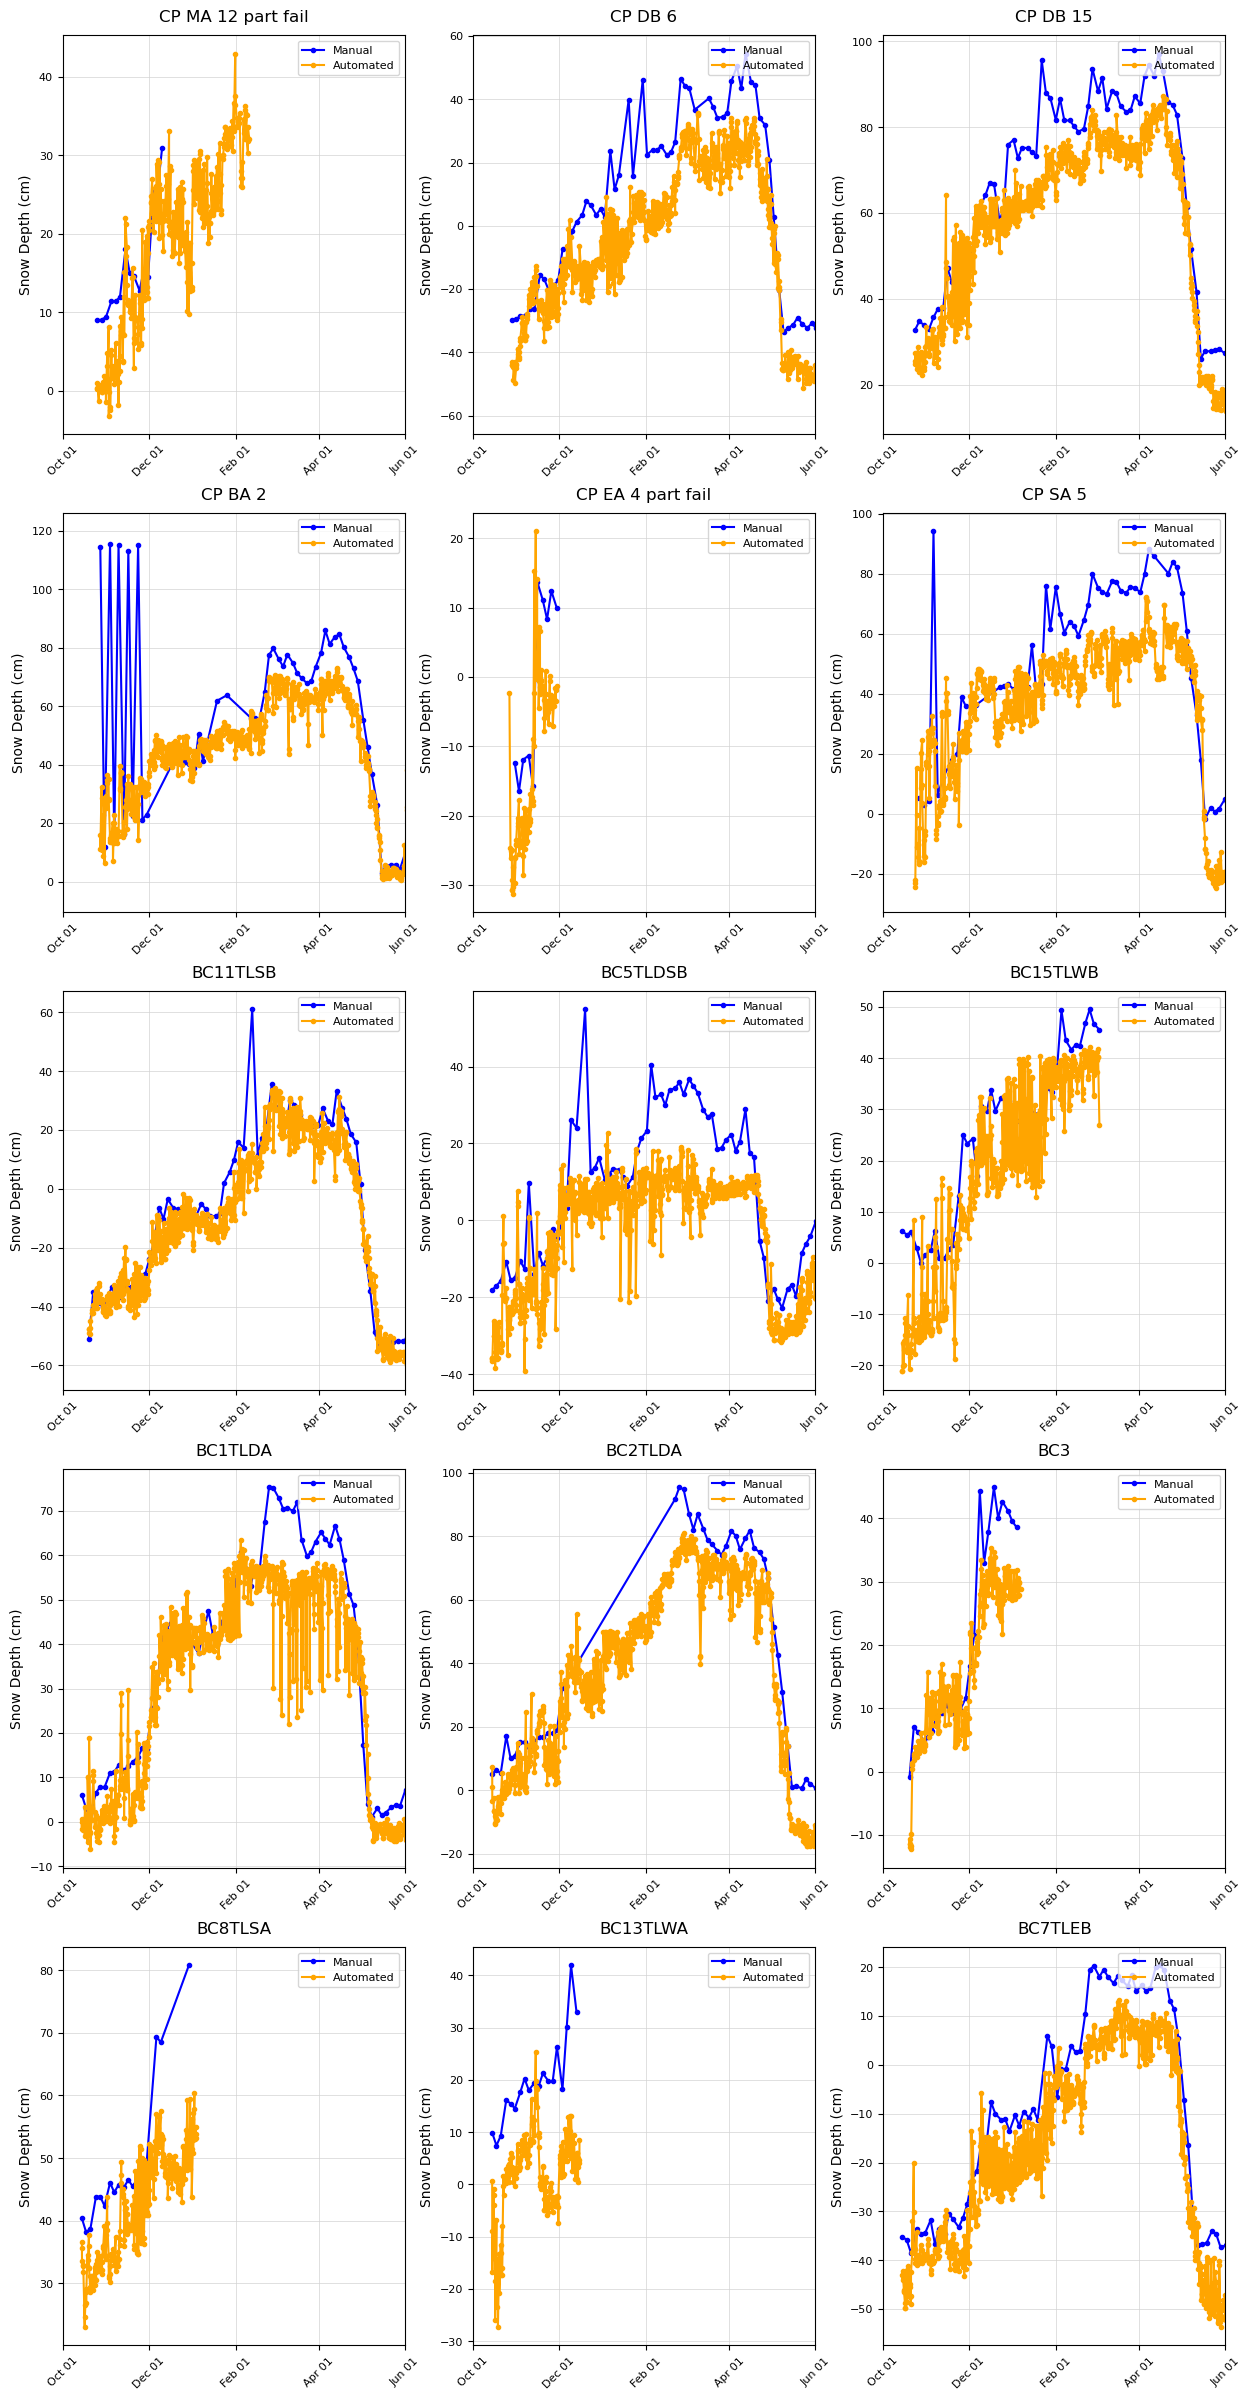

In [11]:


# Convert datetime column to proper datetime format
manual['datetime'] = pd.to_datetime(manual['datetime'])
automated['datetime'] = pd.to_datetime(automated['datetime'])

# Define the date range
start_date = '2022-10-01'
end_date = '2023-06-01'

# Filter the dataframes
manual_filtered = manual[(manual['datetime'] >= start_date) & (manual['datetime'] <= end_date)]
automated_filtered = automated[(automated['datetime'] >= start_date) & (automated['datetime'] <= end_date)]

# Define x-axis limits and tick locations
x_min = datetime(2022, 10, 1)
x_max = datetime(2023, 6, 1)
tick_dates = [
    datetime(2022, 10, 1),
    datetime(2022, 12, 1),
    datetime(2023, 2, 1),
    datetime(2023, 4, 1),
    datetime(2023, 6, 1)
]


fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes_flat = axes.flatten() # flatten axes for easier indexign

# Plot each camera's data
for i, camera_id in enumerate(unique_cameras):
    camera_dataM = manual[manual['cameraID'] == camera_id].sort_values('datetime')
    camera_dataA = automated[automated['camera_id'] == camera_id].sort_values('datetime')

    
    # Plot on the corresponding subplot
    ax = axes_flat[i]
    ax.plot(camera_dataM['datetime'], camera_dataM['SnowDepths2'], 
            color='blue', linewidth=1.5, marker='o', markersize=3, label='Manual')
    ax.plot(camera_dataA['datetime'], camera_dataA['snow_depth2'], 
            color='orange', linewidth=1.5, marker='o', markersize=3, label='Automated')
    
    # Customize subplot
    ax.set_title(f'{camera_id}', fontsize=12, pad=10)
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel('Snow Depth (cm)', fontsize=10)
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    #ax.set_ylim(0, 140)
    ax.set_xlim(x_min, x_max)
    ax.set_xticks(tick_dates)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    ax.legend(loc='upper right', fontsize=8)

In [12]:
## calculate overall error : 

In [13]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Dictionary to store error statistics for each camera
error_stats = {}

# Calculate error statistics for each camera
for camera_id in unique_cameras:
    # Get data for this camera
    camera_dataM = manual_filtered[manual_filtered['cameraID'] == camera_id].sort_values('datetime')
    camera_dataA = automated_filtered[automated_filtered['camera_id'] == camera_id].sort_values('datetime')
    
    # Merge datasets on datetime to align measurements
    merged = pd.merge(camera_dataM[['datetime', 'SnowDepths2']], 
                     camera_dataA[['datetime', 'snow_depth2']], 
                     on='datetime', how='inner')
    
    if len(merged) > 0:
        manual_values = merged['SnowDepths2']
        automated_values = merged['snow_depth2']
        differences = automated_values - manual_values
        
        # Calculate error statistics
        overall_diff = np.mean(differences)  # Mean difference
        std_diff = np.std(differences, ddof=1)  # Standard deviation of differences
        mae = mean_absolute_error(manual_values, automated_values)
        
        # Calculate MAPE (only for non-zero manual values to avoid division by zero)
        non_zero_mask = manual_values != 0
        if non_zero_mask.sum() > 0:
            mape = mean_absolute_percentage_error(manual_values[non_zero_mask], 
                                                automated_values[non_zero_mask])
        else:
            mape = np.nan
        
        # Store results
        error_stats[camera_id] = {
            'n_observations': len(merged),
            'mean_difference_cm': overall_diff,
            'std_difference_cm': std_diff,
            'mae_cm': mae,
            'mape_percent': mape
        }
    else:
        error_stats[camera_id] = {
            'n_observations': 0,
            'mean_difference_cm': np.nan,
            'std_difference_cm': np.nan,
            'mae_cm': np.nan,
            'mape_percent': np.nan
        }

# Print results
print("Error Statistics by Camera:")
print("=" * 90)
for camera_id, stats in error_stats.items():
    print(f"\n{camera_id}:")
    print(f"  Observations: {stats['n_observations']}")
    print(f"  Mean Difference: {stats['mean_difference_cm']:.2f} cm")
    print(f"  Std Difference: {stats['std_difference_cm']:.2f} cm")
    print(f"  MAE: {stats['mae_cm']:.2f} cm")
    print(f"  MAPE: {stats['mape_percent']:.2f}%")

# Calculate overall statistics across all cameras
all_manual = []
all_automated = []

for camera_id in unique_cameras:
    camera_dataM = manual_filtered[manual_filtered['cameraID'] == camera_id].sort_values('datetime')
    camera_dataA = automated_filtered[automated_filtered['camera_id'] == camera_id].sort_values('datetime')
    
    merged = pd.merge(camera_dataM[['datetime', 'SnowDepths2']], 
                     camera_dataA[['datetime', 'snow_depth2']], 
                     on='datetime', how='inner')
    
    if len(merged) > 0:
        all_manual.extend(merged['SnowDepths2'].tolist())
        all_automated.extend(merged['snow_depth2'].tolist())

if len(all_manual) > 0:
    all_manual = np.array(all_manual)
    all_automated = np.array(all_automated)
    all_differences = all_automated - all_manual
    
    overall_mean_diff = np.mean(all_differences)
    overall_std_diff = np.std(all_differences, ddof=1)
    overall_mae = mean_absolute_error(all_manual, all_automated)
    
    non_zero_mask = all_manual != 0
    if non_zero_mask.sum() > 0:
        overall_mape = mean_absolute_percentage_error(all_manual[non_zero_mask], 
                                                    all_automated[non_zero_mask])
    else:
        overall_mape = np.nan
    
    print("\n" + "=" * 90)
    print("OVERALL STATISTICS:")
    print(f"Total Observations: {len(all_manual)}")
    print(f"Overall Mean Difference: {overall_mean_diff:.2f} cm")
    print(f"Overall Std Difference: {overall_std_diff:.2f} cm")
    print(f"Overall MAE: {overall_mae:.2f} cm")
    print(f"Overall MAPE: {overall_mape:.2f}%")

Error Statistics by Camera:

CP MA 12 part fail:
  Observations: 16
  Mean Difference: -5.66 cm
  Std Difference: 4.07 cm
  MAE: 6.17 cm
  MAPE: 51.14%

CP DB 6:
  Observations: 61
  Mean Difference: -15.17 cm
  Std Difference: 8.57 cm
  MAE: 15.39 cm
  MAPE: 127.65%

CP DB 15:
  Observations: 67
  Mean Difference: -9.17 cm
  Std Difference: 5.90 cm
  MAE: 9.62 cm
  MAPE: 15.85%

CP BA 2:
  Observations: 53
  Mean Difference: -14.39 cm
  Std Difference: 26.78 cm
  MAE: 15.82 cm
  MAPE: 25.60%

CP EA 4 part fail:
  Observations: 10
  Mean Difference: -11.40 cm
  Std Difference: 4.38 cm
  MAE: 11.40 cm
  MAPE: 98.29%

CP SA 5:
  Observations: 58
  Mean Difference: -15.45 cm
  Std Difference: 13.09 cm
  MAE: 16.95 cm
  MAPE: 170.07%

BC11TLSB:
  Observations: 67
  Mean Difference: -4.65 cm
  Std Difference: 8.16 cm
  MAE: 6.47 cm
  MAPE: 53.70%

BC5TLDSB:
  Observations: 68
  Mean Difference: -12.99 cm
  Std Difference: 9.57 cm
  MAE: 13.75 cm
  MAPE: 82.82%

BC15TLWB:
  Observations: 44


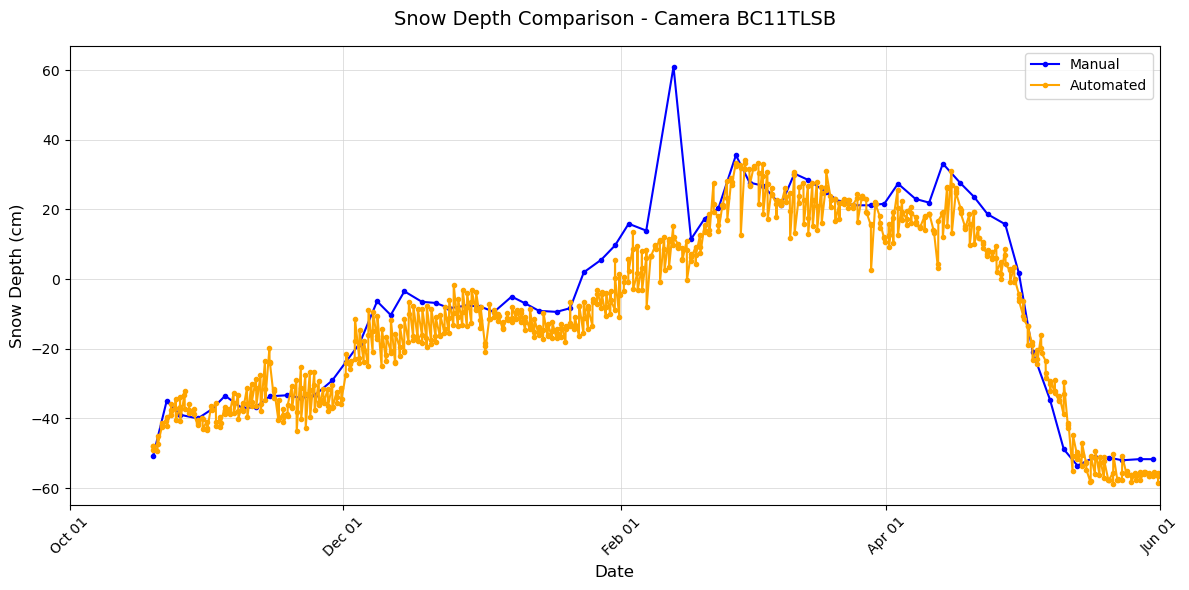

In [17]:
### just look at camera BCTL11SB -- why is it jumpy?

# Convert datetime column to proper datetime format
manual['datetime'] = pd.to_datetime(manual['datetime'])
automated['datetime'] = pd.to_datetime(automated['datetime'])

# Define the date range
start_date = '2022-10-01'
end_date = '2023-06-01'

# Filter for camera 'bctl11sb' and date range
camera_id = 'BC11TLSB'
manual_filtered = manual[
    (manual['cameraID'] == camera_id) & 
    (manual['datetime'] >= start_date) & 
    (manual['datetime'] <= end_date)
].sort_values('datetime')

automated_filtered = automated[
    (automated['camera_id'] == camera_id) & 
    (automated['datetime'] >= start_date) & 
    (automated['datetime'] <= end_date)
].sort_values('datetime')

# Define x-axis limits and tick locations
x_min = datetime(2022, 10, 1)
x_max = datetime(2023, 6, 1)
tick_dates = [
    datetime(2022, 10, 1),
    datetime(2022, 12, 1),
    datetime(2023, 2, 1),
    datetime(2023, 4, 1),
    datetime(2023, 6, 1)
]

# Create single plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the data
ax.plot(manual_filtered['datetime'], manual_filtered['SnowDepths2'], 
        color='blue', linewidth=1.5, marker='o', markersize=3, label='Manual')
ax.plot(automated_filtered['datetime'], automated_filtered['snow_depth2'], 
        color='orange', linewidth=1.5, marker='o', markersize=3, label='Automated')

# Customize plot
ax.set_title(f'Snow Depth Comparison - Camera {camera_id}', fontsize=14, pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Snow Depth (cm)', fontsize=12)
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
ax.set_facecolor('white')
ax.set_axisbelow(True)
ax.set_xlim(x_min, x_max)
ax.set_xticks(tick_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

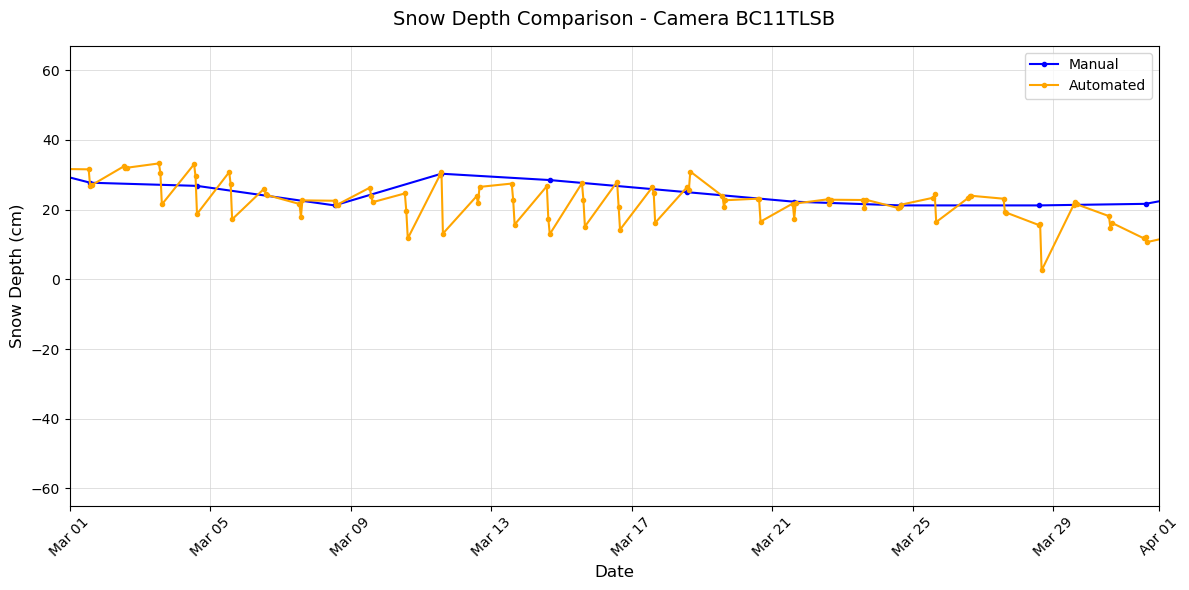

In [19]:
### just look at camera BCTL11SB -- why is it jumpy?

# Convert datetime column to proper datetime format
manual['datetime'] = pd.to_datetime(manual['datetime'])
automated['datetime'] = pd.to_datetime(automated['datetime'])

# Define the date range
start_date = '2022-10-01'
end_date = '2023-06-01'

# Filter for camera 'bctl11sb' and date range
camera_id = 'BC11TLSB'
manual_filtered = manual[
    (manual['cameraID'] == camera_id) & 
    (manual['datetime'] >= start_date) & 
    (manual['datetime'] <= end_date)
].sort_values('datetime')

automated_filtered = automated[
    (automated['camera_id'] == camera_id) & 
    (automated['datetime'] >= start_date) & 
    (automated['datetime'] <= end_date)
].sort_values('datetime')

# Define x-axis limits and tick locations
x_min = datetime(2023, 3, 1)
x_max = datetime(2023, 4, 1)


# Create single plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the data
ax.plot(manual_filtered['datetime'], manual_filtered['SnowDepths2'], 
        color='blue', linewidth=1.5, marker='o', markersize=3, label='Manual')
ax.plot(automated_filtered['datetime'], automated_filtered['snow_depth2'], 
        color='orange', linewidth=1.5, marker='o', markersize=3, label='Automated')

# Customize plot
ax.set_title(f'Snow Depth Comparison - Camera {camera_id}', fontsize=14, pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Snow Depth (cm)', fontsize=12)
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
ax.set_facecolor('white')
ax.set_axisbelow(True)
ax.set_xlim(x_min, x_max)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

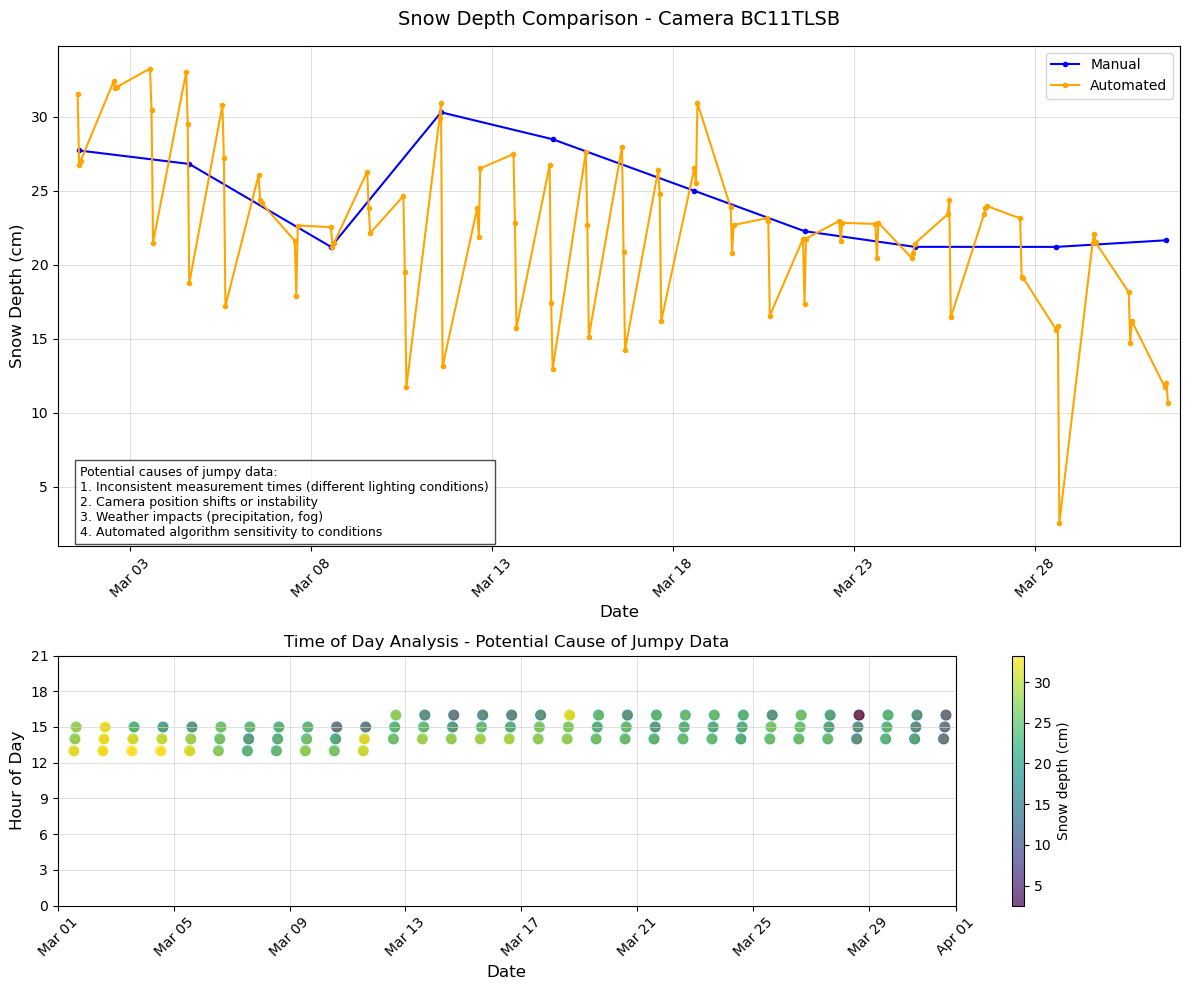


Diagnostic Statistics:
Number of automated measurements: 93
Measurements per day: 3.0
Time between measurements (hours): Mean=7.9, Min=1.0, Max=23.0
Std dev of snow depth: 5.67 cm

Large jumps (>5cm) detected: 31
Time pattern of jumps:
                datetime  hour  snow_depth2  depth_change
4333 2023-03-02 13:00:00    13    32.414550      5.393577
4167 2023-03-03 15:00:00    15    21.489883     -8.969446
4198 2023-03-04 13:00:00    13    33.022153     11.532270
4972 2023-03-04 15:00:00    15    18.736504    -10.803350
4460 2023-03-05 13:00:00    13    30.771017     12.034513
4491 2023-03-05 15:00:00    15    17.213955    -10.004763
4520 2023-03-06 13:00:00    13    26.055392      8.841438
4492 2023-03-10 14:00:00    14    19.487071     -5.160018
4519 2023-03-10 15:00:00    15    11.739634     -7.747436
4837 2023-03-11 13:00:00    13    29.935480     18.195845


In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import pandas as pd
import numpy as np

# Convert datetime column to proper datetime format
manual['datetime'] = pd.to_datetime(manual['datetime'])
automated['datetime'] = pd.to_datetime(automated['datetime'])

# Define the date range
start_date = '2023-03-01'
end_date = '2023-04-01'

# Filter for camera and date range
camera_id = 'BC11TLSB'
manual_filtered = manual[
    (manual['cameraID'] == camera_id) & 
    (manual['datetime'] >= start_date) & 
    (manual['datetime'] <= end_date)
].sort_values('datetime')

automated_filtered = automated[
    (automated['camera_id'] == camera_id) & 
    (automated['datetime'] >= start_date) & 
    (automated['datetime'] <= end_date)
].sort_values('datetime')

# Define x-axis limits
x_min = datetime(2023, 3, 1)
x_max = datetime(2023, 4, 1)

# Create figure with two subplots - main plot and time of day analysis
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

# Plot the snow depth data
ax.plot(manual_filtered['datetime'], manual_filtered['SnowDepths2'], 
        color='blue', linewidth=1.5, marker='o', markersize=3, label='Manual')
ax.plot(automated_filtered['datetime'], automated_filtered['snow_depth2'], 
        color='orange', linewidth=1.5, marker='o', markersize=3, label='Automated')

# Add date and hour labels to main plot
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.tick_params(axis='x', rotation=45, labelsize=10)

# Customize main plot
ax.set_title(f'Snow Depth Comparison - Camera {camera_id}', fontsize=14, pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Snow Depth (cm)', fontsize=12)
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
ax.set_facecolor('white')
ax.set_axisbelow(True)
ax.set_xlim(x_min, x_max)
ax.legend(loc='upper right', fontsize=10)

# Extract hour of day for both datasets to analyze time-of-day patterns
if not automated_filtered.empty:
    automated_filtered['hour'] = automated_filtered['datetime'].dt.hour
    
    # Plot time of day analysis
    ax2.scatter(automated_filtered['datetime'], automated_filtered['hour'], 
                color='orange', s=30, alpha=0.7, label='Measurement time')
    
    # Add snow depth as color intensity
    if 'snow_depth2' in automated_filtered.columns:
        scatter = ax2.scatter(automated_filtered['datetime'], automated_filtered['hour'], 
                   c=automated_filtered['snow_depth2'], cmap='viridis', 
                   s=50, alpha=0.7)
        plt.colorbar(scatter, ax=ax2, label='Snow depth (cm)')

    # Customize time of day plot
    ax2.set_title('Time of Day Analysis - Potential Cause of Jumpy Data', fontsize=12)
    ax2.set_ylabel('Hour of Day', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_yticks(range(0, 24, 3))
    ax2.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax2.set_xlim(x_min, x_max)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax2.tick_params(axis='x', rotation=45)

# Add text explaining potential causes of jumpy data
ax.text(0.02, 0.02, 
         "Potential causes of jumpy data:\n"
         "1. Inconsistent measurement times (different lighting conditions)\n"
         "2. Camera position shifts or instability\n"
         "3. Weather impacts (precipitation, fog)\n"
         "4. Automated algorithm sensitivity to conditions",
         transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7),
         fontsize=9)

plt.tight_layout()
plt.show()

# Print additional diagnostics
if not automated_filtered.empty:
    print("\nDiagnostic Statistics:")
    print(f"Number of automated measurements: {len(automated_filtered)}")
    print(f"Measurements per day: {len(automated_filtered)/31:.1f}")
    print(f"Time between measurements (hours): "
          f"Mean={automated_filtered['datetime'].diff().dt.total_seconds().mean()/3600:.1f}, "
          f"Min={automated_filtered['datetime'].diff().dt.total_seconds().min()/3600:.1f}, "
          f"Max={automated_filtered['datetime'].diff().dt.total_seconds().max()/3600:.1f}")
    print(f"Std dev of snow depth: {automated_filtered['snow_depth2'].std():.2f} cm")
    
    # Check for patterns in jumps
    automated_filtered['depth_change'] = automated_filtered['snow_depth2'].diff()
    large_jumps = automated_filtered[abs(automated_filtered['depth_change']) > 5]
    if not large_jumps.empty:
        print(f"\nLarge jumps (>5cm) detected: {len(large_jumps)}")
        print("Time pattern of jumps:")
        print(large_jumps[['datetime', 'hour', 'snow_depth2', 'depth_change']].head(10))

In [22]:
manual

,cameraID,filename,datetime,x1,y1,x2,y2,PixelLengths,SnowDepths,Storm_Flag,Vegetation_Flag,Pole_Tilt_Flag,SnowDepths2
0,BC11TLSB,BC11TLSB_WSCT1713.JPG,2023-08-20 14:00:00,210.932727,99.281818,208.023636,309.900000,210.638271,0.506899,0,0,0,1.354671
1,BC11TLSB,BC11TLSB_WSCT1724.JPG,2023-08-23 16:00:00,208.023636,99.572727,210.350909,309.318182,209.758365,1.025626,0,0,0,1.812903
2,BC11TLSB,BC11TLSB_WSCT1734.JPG,2023-08-27 14:00:00,209.769091,100.445455,208.605455,309.900000,209.457778,1.202831,0,0,0,1.969441
3,BC11TLSB,BC11TLSB_WSCT1744.JPG,2023-08-30 15:00:00,210.932727,99.281818,210.641818,308.154545,208.872930,1.547614,0,0,0,2.274014
4,BC11TLSB,BC11TLSB_WSCT1754.JPG,2023-09-02 16:00:00,210.060000,99.281818,208.605455,309.609091,210.332302,0.687275,0,0,0,1.514012
...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,CP SA 5,CP SA 5_WSCT1183.JPG,2023-08-12 15:00:00,201.041818,198.190909,195.805455,361.100000,162.993225,2.250044,0,0,0,8.616505
916,CP SA 5,CP SA 5_WSCT1193.JPG,2023-08-15 16:00:00,201.332727,200.227273,197.841818,350.918182,150.731339,11.607525,0,0,0,17.216803
917,CP SA 5,CP SA 5_WSCT1203.JPG,2023-08-19 14:00:00,202.205455,200.227273,196.678182,349.463636,149.338685,12.670308,0,0,0,18.193589
918,CP SA 5,CP SA 5_WSCT1213.JPG,2023-08-22 15:00:00,201.041818,200.518182,197.841818,358.481818,157.996046,6.063569,0,0,0,12.121450


Found 925 exact matches between manual and automated measurements


/var/folders/hj/wb6c_bx91hd1rh23yw_npmdr0000gp/T/ipykernel_75954/906665058.py:84: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_accuracy = matched_data.groupby('hour').apply(calculate_accuracy_metrics).reset_index()


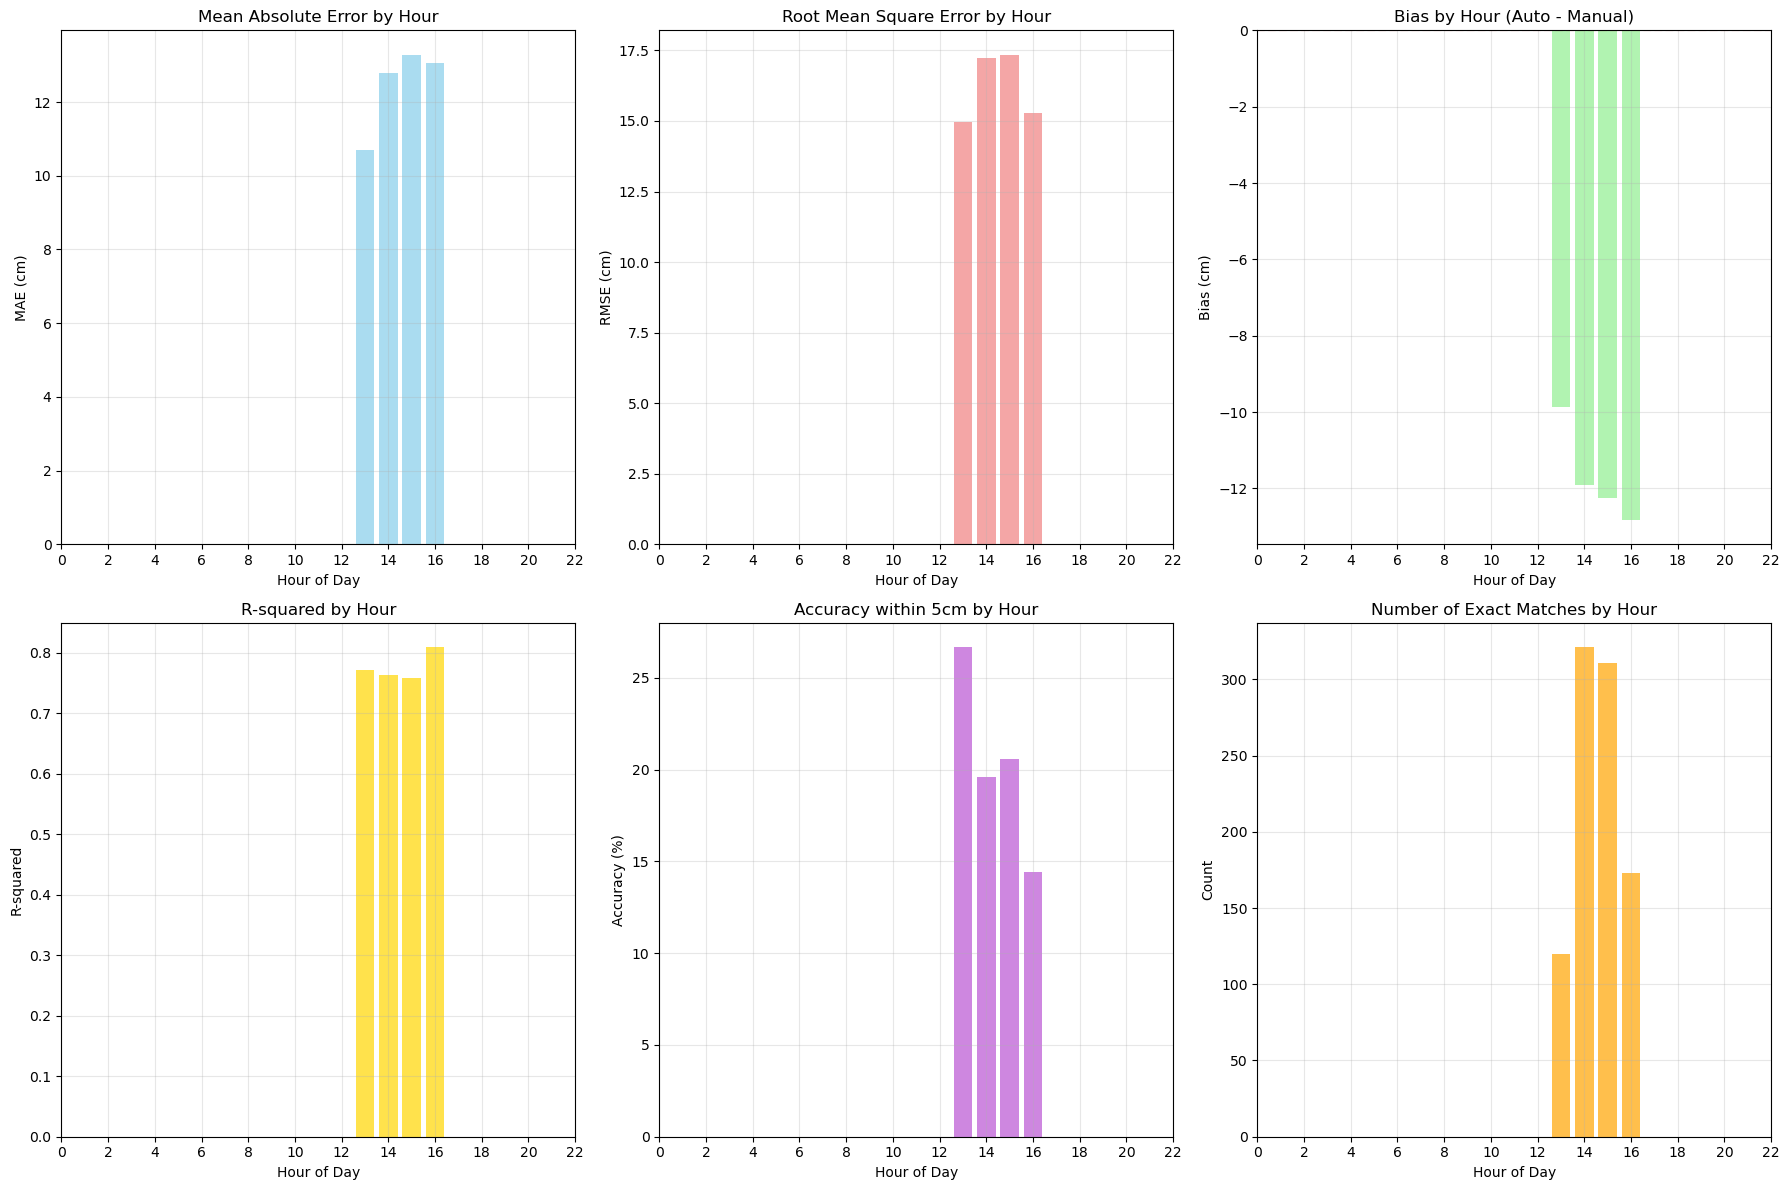


Hourly Accuracy Summary (Exact DateTime Matches):
Hour Count  MAE      RMSE     Bias     R²       Acc5cm   Acc10cm 


ValueError: Unknown format code 'd' for object of type 'float'

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure datetime columns are properly formatted
manual['datetime'] = pd.to_datetime(manual['datetime'])
automated['datetime'] = pd.to_datetime(automated['datetime'])

# Create matching keys using camera_id and exact datetime
manual_analysis = manual.copy()
automated_analysis = automated.copy()

# Standardize column names
manual_analysis.rename(columns={'cameraID': 'camera_id', 'SnowDepths2': 'snow_depth_manual'}, inplace=True)
automated_analysis.rename(columns={'snow_depth2': 'snow_depth_auto'}, inplace=True)

# Create matching key
manual_analysis['match_key'] = manual_analysis['camera_id'].astype(str) + '_' + manual_analysis['datetime'].astype(str)
automated_analysis['match_key'] = automated_analysis['camera_id'].astype(str) + '_' + automated_analysis['datetime'].astype(str)

# Merge on exact datetime and camera matches
matched_data = pd.merge(
    manual_analysis[['match_key', 'camera_id', 'datetime', 'snow_depth_manual']], 
    automated_analysis[['match_key', 'camera_id', 'datetime', 'snow_depth_auto']], 
    on='match_key', 
    suffixes=('_manual', '_auto')
)

# Use the manual datetime and add hour column
matched_data['hour'] = matched_data['datetime_manual'].dt.hour

if not matched_data.empty:
    print(f"Found {len(matched_data)} exact matches between manual and automated measurements")
    
    # Calculate accuracy metrics per hour
    def calculate_accuracy_metrics(group):
        manual_vals = group['snow_depth_manual']
        auto_vals = group['snow_depth_auto']
        
        # Remove any NaN values
        valid_mask = ~(pd.isna(manual_vals) | pd.isna(auto_vals))
        manual_vals = manual_vals[valid_mask]
        auto_vals = auto_vals[valid_mask]
        
        if len(manual_vals) == 0:
            return pd.Series({
                'count': 0,
                'mae': np.nan,
                'rmse': np.nan,
                'bias': np.nan,
                'r_squared': np.nan,
                'accuracy_5cm': np.nan,
                'accuracy_10cm': np.nan
            })
        
        # Calculate metrics
        mae = np.mean(np.abs(manual_vals - auto_vals))
        rmse = np.sqrt(np.mean((manual_vals - auto_vals)**2))
        bias = np.mean(auto_vals - manual_vals)
        
        # R-squared
        if len(manual_vals) > 1:
            ss_res = np.sum((manual_vals - auto_vals)**2)
            ss_tot = np.sum((manual_vals - np.mean(manual_vals))**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        else:
            r_squared = np.nan
        
        # Accuracy within thresholds
        accuracy_5cm = np.mean(np.abs(manual_vals - auto_vals) <= 5) * 100
        accuracy_10cm = np.mean(np.abs(manual_vals - auto_vals) <= 10) * 100
        
        return pd.Series({
            'count': len(manual_vals),
            'mae': mae,
            'rmse': rmse,
            'bias': bias,
            'r_squared': r_squared,
            'accuracy_5cm': accuracy_5cm,
            'accuracy_10cm': accuracy_10cm
        })
    
    # Group by hour and calculate metrics
    hourly_accuracy = matched_data.groupby('hour').apply(calculate_accuracy_metrics).reset_index()
    
    # Filter out hours with no data
    hourly_accuracy = hourly_accuracy[hourly_accuracy['count'] > 0]
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: MAE by hour
    axes[0,0].bar(hourly_accuracy['hour'], hourly_accuracy['mae'], color='skyblue', alpha=0.7)
    axes[0,0].set_title('Mean Absolute Error by Hour')
    axes[0,0].set_xlabel('Hour of Day')
    axes[0,0].set_ylabel('MAE (cm)')
    axes[0,0].set_xticks(range(0, 24, 2))
    axes[0,0].grid(True, alpha=0.3)
    
    # Plot 2: RMSE by hour
    axes[0,1].bar(hourly_accuracy['hour'], hourly_accuracy['rmse'], color='lightcoral', alpha=0.7)
    axes[0,1].set_title('Root Mean Square Error by Hour')
    axes[0,1].set_xlabel('Hour of Day')
    axes[0,1].set_ylabel('RMSE (cm)')
    axes[0,1].set_xticks(range(0, 24, 2))
    axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Bias by hour
    axes[0,2].bar(hourly_accuracy['hour'], hourly_accuracy['bias'], color='lightgreen', alpha=0.7)
    axes[0,2].set_title('Bias by Hour (Auto - Manual)')
    axes[0,2].set_xlabel('Hour of Day')
    axes[0,2].set_ylabel('Bias (cm)')
    axes[0,2].set_xticks(range(0, 24, 2))
    axes[0,2].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[0,2].grid(True, alpha=0.3)
    
    # Plot 4: R-squared by hour
    valid_r2 = hourly_accuracy[~pd.isna(hourly_accuracy['r_squared'])]
    axes[1,0].bar(valid_r2['hour'], valid_r2['r_squared'], color='gold', alpha=0.7)
    axes[1,0].set_title('R-squared by Hour')
    axes[1,0].set_xlabel('Hour of Day')
    axes[1,0].set_ylabel('R-squared')
    axes[1,0].set_xticks(range(0, 24, 2))
    axes[1,0].grid(True, alpha=0.3)
    
    # Plot 5: Accuracy within 5cm
    axes[1,1].bar(hourly_accuracy['hour'], hourly_accuracy['accuracy_5cm'], color='mediumorchid', alpha=0.7)
    axes[1,1].set_title('Accuracy within 5cm by Hour')
    axes[1,1].set_xlabel('Hour of Day')
    axes[1,1].set_ylabel('Accuracy (%)')
    axes[1,1].set_xticks(range(0, 24, 2))
    axes[1,1].grid(True, alpha=0.3)
    
    # Plot 6: Sample count by hour
    axes[1,2].bar(hourly_accuracy['hour'], hourly_accuracy['count'], color='orange', alpha=0.7)
    axes[1,2].set_title('Number of Exact Matches by Hour')
    axes[1,2].set_xlabel('Hour of Day')
    axes[1,2].set_ylabel('Count')
    axes[1,2].set_xticks(range(0, 24, 2))
    axes[1,2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\nHourly Accuracy Summary (Exact DateTime Matches):")
    print("=" * 85)
    print(f"{'Hour':<4} {'Count':<6} {'MAE':<8} {'RMSE':<8} {'Bias':<8} {'R²':<8} {'Acc5cm':<8} {'Acc10cm':<8}")
    print("=" * 85)
    
    for _, row in hourly_accuracy.iterrows():
        r2_str = f"{row['r_squared']:>6.3f}" if not pd.isna(row['r_squared']) else "   N/A"
        print(f"{row['hour']:>2d}   {row['count']:>4.0f}   "
              f"{row['mae']:>6.2f}   {row['rmse']:>6.2f}   "
              f"{row['bias']:>6.2f}   {r2_str}   "
              f"{row['accuracy_5cm']:>6.1f}%   {row['accuracy_10cm']:>6.1f}%")
    
    # Overall statistics
    print("\n" + "=" * 85)
    print("Overall Statistics:")
    total_matches = matched_data.shape[0]
    overall_mae = np.mean(np.abs(matched_data['snow_depth_manual'] - matched_data['snow_depth_auto']))
    overall_rmse = np.sqrt(np.mean((matched_data['snow_depth_manual'] - matched_data['snow_depth_auto'])**2))
    overall_bias = np.mean(matched_data['snow_depth_auto'] - matched_data['snow_depth_manual'])
    overall_acc5 = np.mean(np.abs(matched_data['snow_depth_manual'] - matched_data['snow_depth_auto']) <= 5) * 100
    overall_acc10 = np.mean(np.abs(matched_data['snow_depth_manual'] - matched_data['snow_depth_auto']) <= 10) * 100
    
    print(f"Total exact matches: {total_matches}")
    print(f"Overall MAE: {overall_mae:.2f} cm")
    print(f"Overall RMSE: {overall_rmse:.2f} cm")
    print(f"Overall Bias: {overall_bias:.2f} cm")
    print(f"Overall accuracy within 5cm: {overall_acc5:.1f}%")
    print(f"Overall accuracy within 10cm: {overall_acc10:.1f}%")
    
    # Show which hours have data
    print(f"\nHours with data: {sorted(hourly_accuracy['hour'].tolist())}")
    
else:
    print("No exact matches found between manual and automated datasets.")
    print("Check that:")
    print("1. Camera IDs are exactly the same format")
    print("2. Datetime values are exactly the same")
    print("3. Both datasets have overlapping camera-datetime combinations")
    
    # Show some sample data for debugging
    print("\nSample manual data:")
    print(manual_analysis[['camera_id', 'datetime']].head())
    print("\nSample automated data:")
    print(automated_analysis[['camera_id', 'datetime']].head())

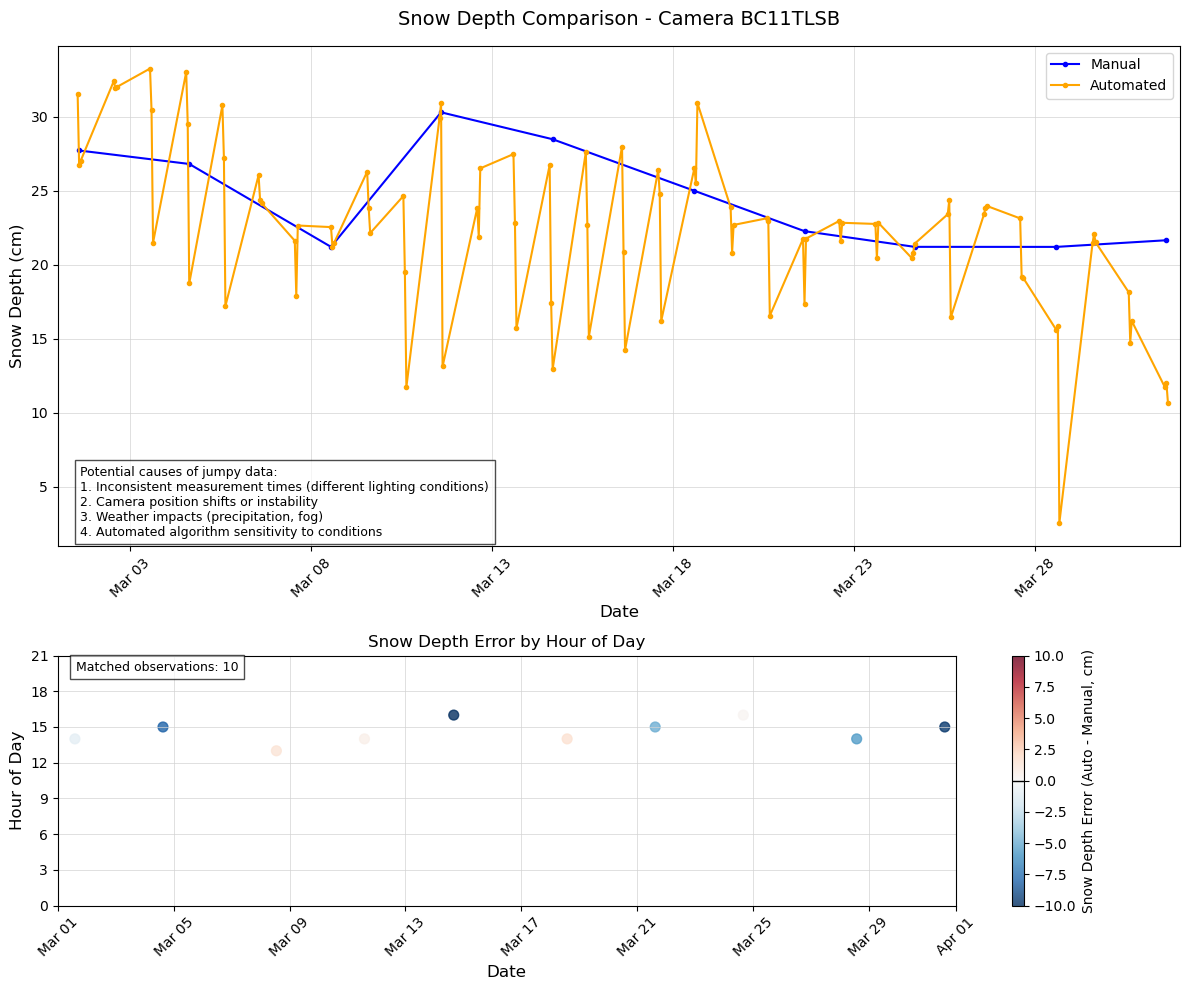


Diagnostic Statistics:
Number of automated measurements: 93
Measurements per day: 3.0
Time between measurements (hours): Mean=7.9, Min=1.0, Max=23.0
Std dev of snow depth: 5.67 cm

Error Statistics (n=10 matched observations):
Mean error (Auto - Manual): -4.11 cm
Std dev of error: 5.69 cm
Mean absolute error: 4.84 cm
RMSE: 6.78 cm

Error by hour of day:
          mean        std  count
hour                            
13    1.334330        NaN      1
14   -1.117559   3.175273      4
15   -7.537159   2.423676      3
16   -7.653953  11.121440      2

Large jumps (>5cm) detected: 31
Time pattern of jumps:
                datetime  hour  snow_depth2  depth_change
4333 2023-03-02 13:00:00    13    32.414550      5.393577
4167 2023-03-03 15:00:00    15    21.489883     -8.969446
4198 2023-03-04 13:00:00    13    33.022153     11.532270
4972 2023-03-04 15:00:00    15    18.736504    -10.803350
4460 2023-03-05 13:00:00    13    30.771017     12.034513
4491 2023-03-05 15:00:00    15    17.2139

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import pandas as pd
import numpy as np

# Convert datetime column to proper datetime format
manual['datetime'] = pd.to_datetime(manual['datetime'])
automated['datetime'] = pd.to_datetime(automated['datetime'])

# Define the date range
start_date = '2023-03-01'
end_date = '2023-04-01'

# Filter for camera and date range
camera_id = 'BC11TLSB'
manual_filtered = manual[
    (manual['cameraID'] == camera_id) & 
    (manual['datetime'] >= start_date) & 
    (manual['datetime'] <= end_date)
].sort_values('datetime')

automated_filtered = automated[
    (automated['camera_id'] == camera_id) & 
    (automated['datetime'] >= start_date) & 
    (automated['datetime'] <= end_date)
].sort_values('datetime')

# Define x-axis limits
x_min = datetime(2023, 3, 1)
x_max = datetime(2023, 4, 1)

# Create figure with two subplots - main plot and time of day analysis
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

# Plot the snow depth data
ax.plot(manual_filtered['datetime'], manual_filtered['SnowDepths2'], 
        color='blue', linewidth=1.5, marker='o', markersize=3, label='Manual')
ax.plot(automated_filtered['datetime'], automated_filtered['snow_depth2'], 
        color='orange', linewidth=1.5, marker='o', markersize=3, label='Automated')

# Add date and hour labels to main plot
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.tick_params(axis='x', rotation=45, labelsize=10)

# Customize main plot
ax.set_title(f'Snow Depth Comparison - Camera {camera_id}', fontsize=14, pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Snow Depth (cm)', fontsize=12)
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
ax.set_facecolor('white')
ax.set_axisbelow(True)
ax.set_xlim(x_min, x_max)
ax.legend(loc='upper right', fontsize=10)

# Calculate snow depth error for time-of-day analysis
if not automated_filtered.empty and not manual_filtered.empty:
    # Merge automated and manual data on exact datetime match
    automated_filtered['hour'] = automated_filtered['datetime'].dt.hour
    
    # Create matching key for exact datetime matches
    manual_match = manual_filtered.set_index('datetime')
    automated_match = automated_filtered.set_index('datetime')
    
    # Find common dates between manual and automated
    common_dates = automated_match.index.intersection(manual_match.index)
    
    if len(common_dates) > 0:
        # Calculate errors for matched observations
        matched_auto = automated_match.loc[common_dates]
        matched_manual = manual_match.loc[common_dates]
        
        # Calculate error (automated - manual)
        snow_depth_error = matched_auto['snow_depth2'] - matched_manual['SnowDepths2']
        matched_auto['snow_depth_error'] = snow_depth_error
        
        # Reset index to get datetime back as column
        matched_auto = matched_auto.reset_index()
        
        # Plot time of day analysis with error as color
        scatter = ax2.scatter(matched_auto['datetime'], matched_auto['hour'], 
                   c=matched_auto['snow_depth_error'], cmap='RdBu_r', 
                   s=50, alpha=0.8, vmin=-10, vmax=10)
        
        # Add colorbar for snow depth error
        cbar = plt.colorbar(scatter, ax=ax2, label='Snow Depth Error (Auto - Manual, cm)')
        cbar.ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        
        # Add zero error line on colorbar
        ax2.text(0.02, 0.98, f'Matched observations: {len(matched_auto)}', 
                transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.7),
                fontsize=9, verticalalignment='top')
        
    else:
        # If no exact matches, just plot measurement times
        ax2.scatter(automated_filtered['datetime'], automated_filtered['hour'], 
                    color='orange', s=30, alpha=0.7, label='Measurement time (no manual match)')
        ax2.text(0.02, 0.98, 'No exact datetime matches found between manual and automated', 
                transform=ax2.transAxes, bbox=dict(facecolor='yellow', alpha=0.7),
                fontsize=9, verticalalignment='top')

    # Customize time of day plot
    ax2.set_title('Snow Depth Error by Hour of Day', fontsize=12)
    ax2.set_ylabel('Hour of Day', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_yticks(range(0, 24, 3))
    ax2.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax2.set_xlim(x_min, x_max)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax2.tick_params(axis='x', rotation=45)

# Add text explaining potential causes of jumpy data
ax.text(0.02, 0.02, 
         "Potential causes of jumpy data:\n"
         "1. Inconsistent measurement times (different lighting conditions)\n"
         "2. Camera position shifts or instability\n"
         "3. Weather impacts (precipitation, fog)\n"
         "4. Automated algorithm sensitivity to conditions",
         transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7),
         fontsize=9)

plt.tight_layout()
plt.show()

# Print additional diagnostics
if not automated_filtered.empty:
    print("\nDiagnostic Statistics:")
    print(f"Number of automated measurements: {len(automated_filtered)}")
    print(f"Measurements per day: {len(automated_filtered)/31:.1f}")
    print(f"Time between measurements (hours): "
          f"Mean={automated_filtered['datetime'].diff().dt.total_seconds().mean()/3600:.1f}, "
          f"Min={automated_filtered['datetime'].diff().dt.total_seconds().min()/3600:.1f}, "
          f"Max={automated_filtered['datetime'].diff().dt.total_seconds().max()/3600:.1f}")
    print(f"Std dev of snow depth: {automated_filtered['snow_depth2'].std():.2f} cm")
    
    # Calculate error statistics if we have matches
    if 'matched_auto' in locals() and len(matched_auto) > 0:
        print(f"\nError Statistics (n={len(matched_auto)} matched observations):")
        print(f"Mean error (Auto - Manual): {matched_auto['snow_depth_error'].mean():.2f} cm")
        print(f"Std dev of error: {matched_auto['snow_depth_error'].std():.2f} cm")
        print(f"Mean absolute error: {abs(matched_auto['snow_depth_error']).mean():.2f} cm")
        print(f"RMSE: {np.sqrt((matched_auto['snow_depth_error']**2).mean()):.2f} cm")
        
        # Error by hour
        error_by_hour = matched_auto.groupby('hour')['snow_depth_error'].agg(['mean', 'std', 'count'])
        print(f"\nError by hour of day:")
        print(error_by_hour)
    
    # Check for patterns in jumps
    automated_filtered['depth_change'] = automated_filtered['snow_depth2'].diff()
    large_jumps = automated_filtered[abs(automated_filtered['depth_change']) > 5]
    if not large_jumps.empty:
        print(f"\nLarge jumps (>5cm) detected: {len(large_jumps)}")
        print("Time pattern of jumps:")
        print(large_jumps[['datetime', 'hour', 'snow_depth2', 'depth_change']].head(10))
        

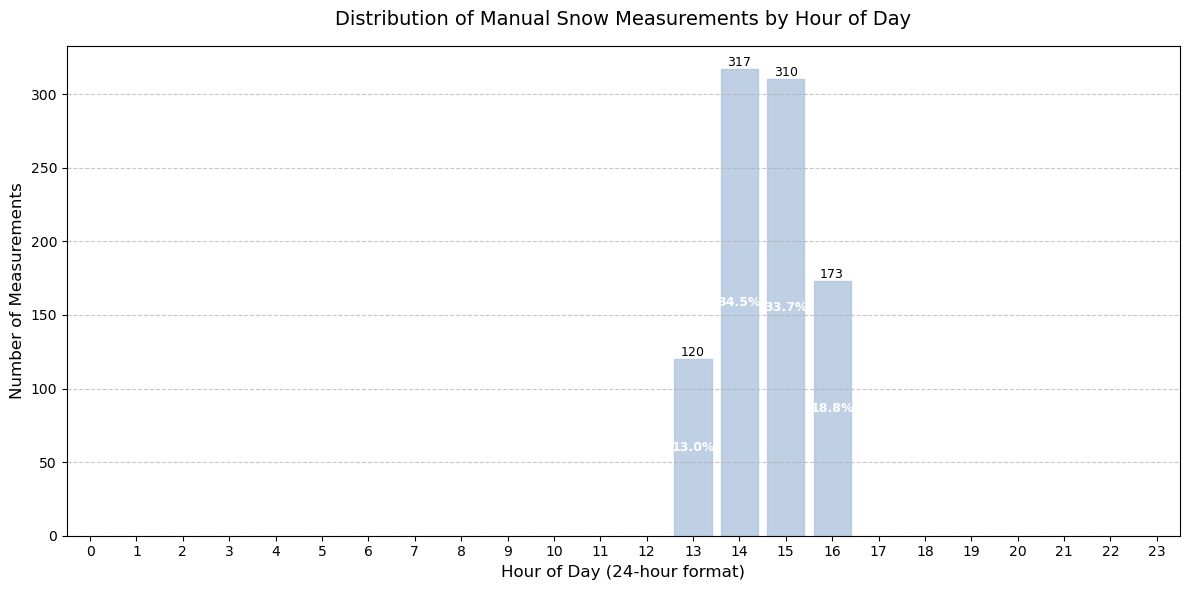

Manual Measurement Time Statistics:
Total number of measurements: 920

Measurements by hour:
      Count  Percentage
hour                   
14      317        34.5
15      310        33.7
16      173        18.8
13      120        13.0

Most common measurement hour: 14:00 (317 measurements, 34.5%)


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

# Ensure datetime column is properly formatted
manual['datetime'] = pd.to_datetime(manual['datetime'])

# Extract hour of day from datetime
manual['hour'] = manual['datetime'].dt.hour

# Count measurements per hour
hour_counts = manual.groupby('hour').size()

# Create a bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Plot frequency by hour
bars = ax.bar(hour_counts.index, hour_counts.values, color='steelblue', alpha=0.8)

# Customize the plot
ax.set_title('Distribution of Manual Snow Measurements by Hour of Day', fontsize=14, pad=15)
ax.set_xlabel('Hour of Day (24-hour format)', fontsize=12)
ax.set_ylabel('Number of Measurements', fontsize=12)
ax.set_xticks(range(0, 24))
ax.set_xlim(-0.5, 23.5)  # Set x-axis limits to show all 24 hours
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.0f}', ha='center', va='bottom', fontsize=9)

# Optional: Add color to highlight business hours
for i, bar in enumerate(bars):
    if 8 <= i <= 17:  # Typical business hours (8 AM to 6 PM)
        bar.set_color('royalblue')
    else:
        bar.set_color('lightsteelblue')

# Add percentage labels
total_measurements = hour_counts.sum()
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_measurements) * 100
    if percentage >= 1:  # Only show percentage for significant bars
        ax.text(bar.get_x() + bar.get_width()/2., height/2,
                f'{percentage:.1f}%', ha='center', va='center', 
                fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("Manual Measurement Time Statistics:")
print(f"Total number of measurements: {total_measurements}")
print("\nMeasurements by hour:")
hour_stats = pd.DataFrame({
    'Count': hour_counts,
    'Percentage': (hour_counts / total_measurements * 100).round(1)
})
print(hour_stats.sort_values('Count', ascending=False))

# Calculate mode hour (most common measurement time)
mode_hour = hour_counts.idxmax()
mode_count = hour_counts.max()
mode_percentage = (mode_count / total_measurements * 100).round(1)
print(f"\nMost common measurement hour: {mode_hour}:00 ({mode_count} measurements, {mode_percentage}%)")

# Count business hours (8am-6pm) vs. non-business hours
business_hours = hour_counts.loc[8:17].sum()
non_business = hour_counts.sum() - business_hours